Cycle: nodes=9 edges=9


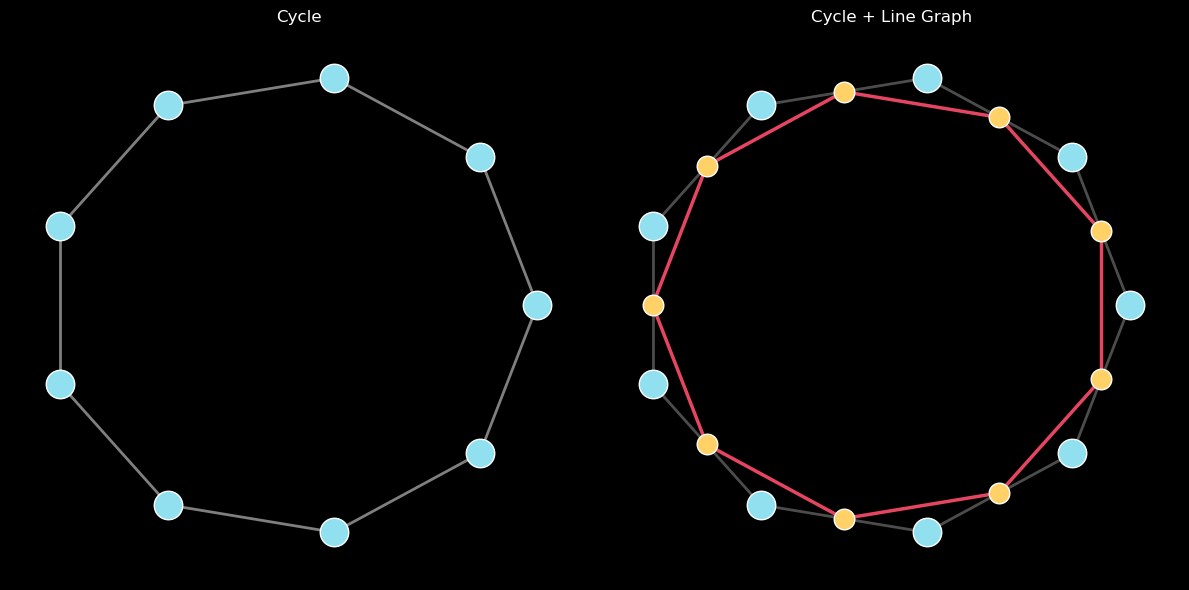

Path: nodes=9 edges=8


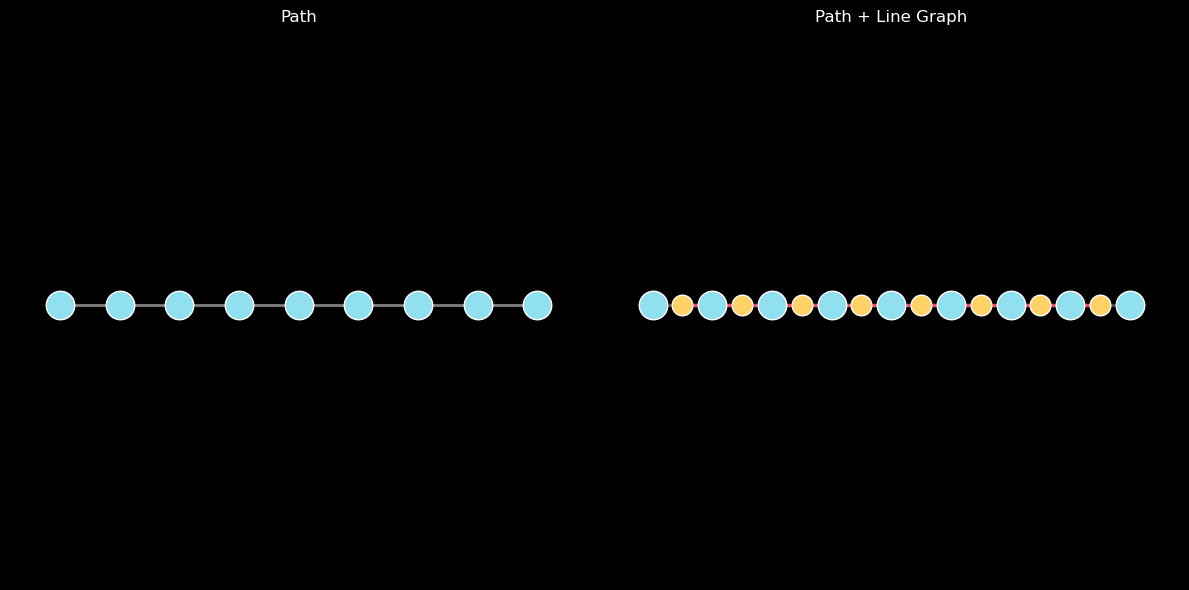

Wheel: nodes=9 edges=16


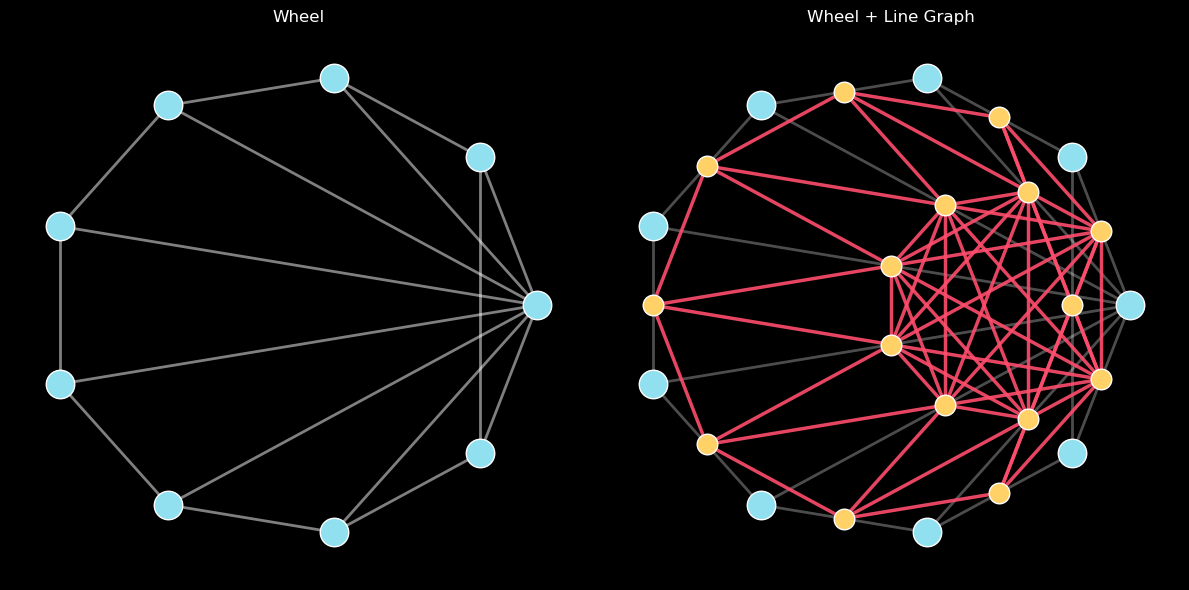

Ladder: nodes=8 edges=10


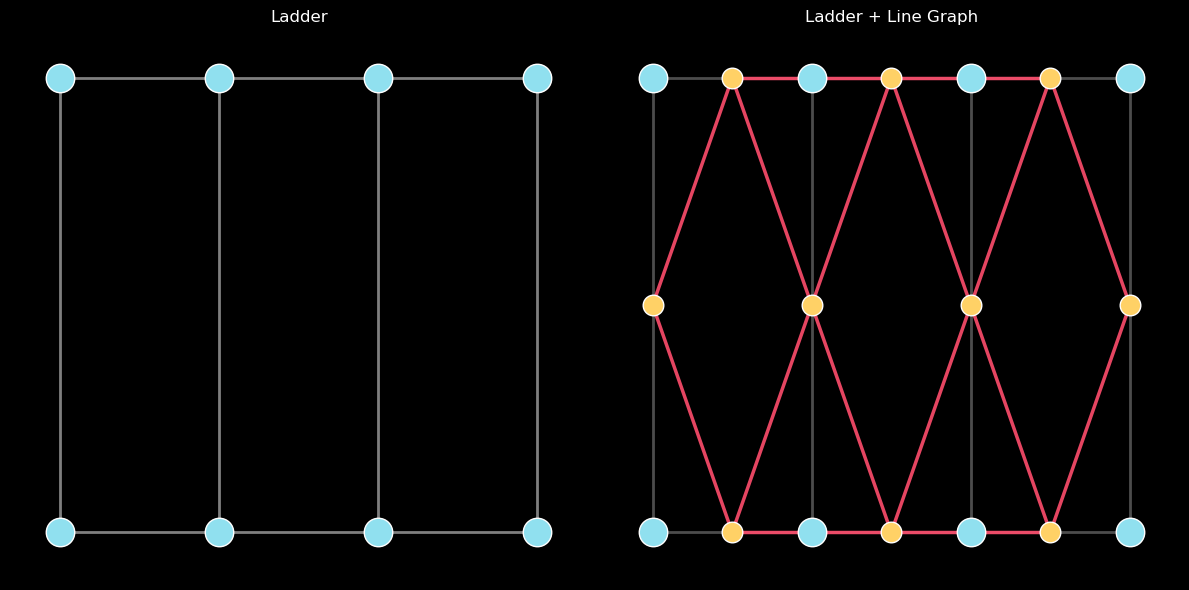

Grid: nodes=9 edges=12


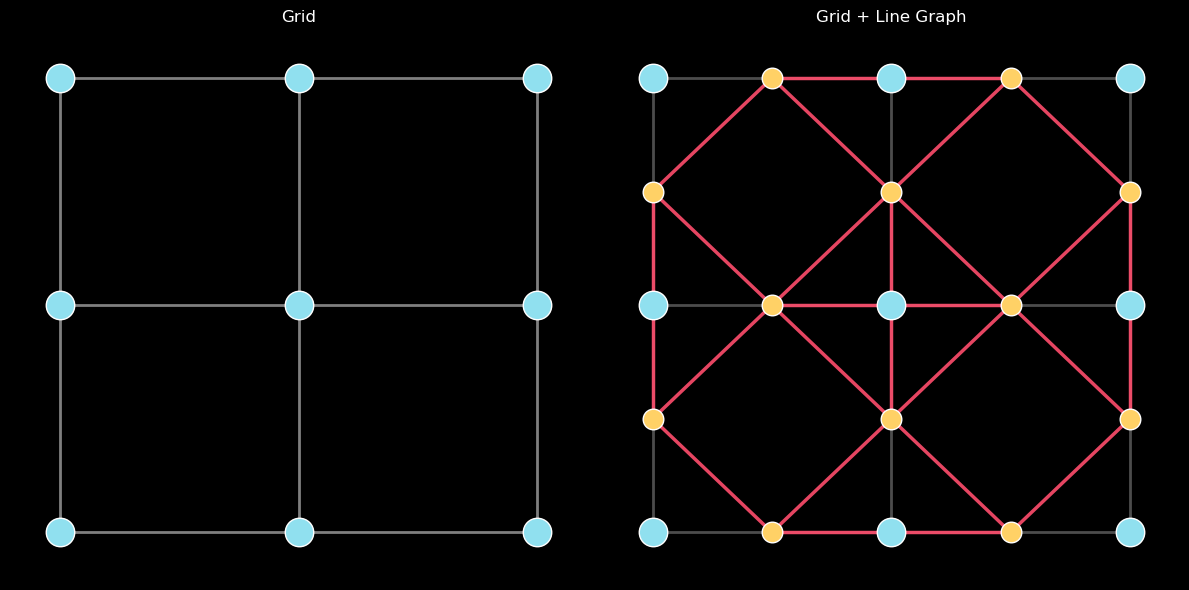

Triangular Lattice: nodes=10 edges=18


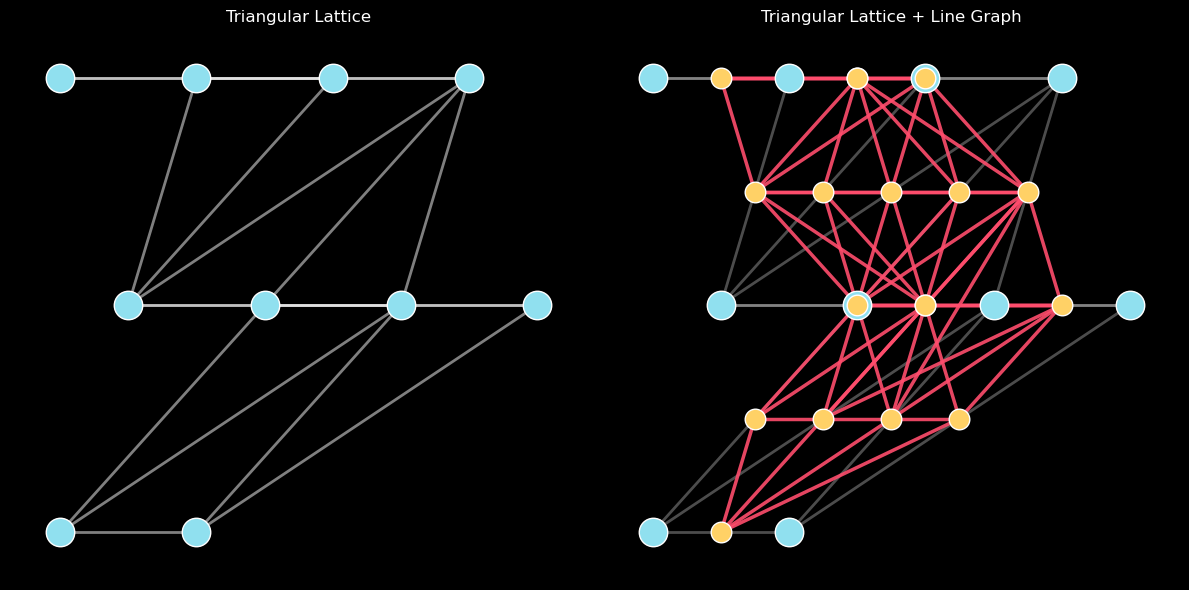

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

plt.style.use("dark_background")

# ============================================================
# Graph generators
# ============================================================
def make_cycle(n):
    return nx.cycle_graph(n)

def make_path(n):
    return nx.path_graph(n)

def make_wheel(n):
    return nx.wheel_graph(max(n, 4))

def make_ladder(n):
    k = max(2, n // 2)
    G = nx.ladder_graph(k)
    return nx.convert_node_labels_to_integers(G)

def make_grid(n):
    rows = int(np.sqrt(n))
    cols = int(np.ceil(n / rows))
    G = nx.grid_2d_graph(rows, cols)
    return nx.convert_node_labels_to_integers(G)

def make_triangular_lattice(n):
    rows = int(np.sqrt(n))
    cols = int(np.ceil(n / rows))
    G = nx.triangular_lattice_graph(rows, cols)
    return nx.convert_node_labels_to_integers(G)

graph_generators = {
    "Cycle": make_cycle,
    "Path": make_path,
    "Wheel": make_wheel,
    "Ladder": make_ladder,
    "Grid": make_grid,
    "Triangular Lattice": make_triangular_lattice
}

# ============================================================
# Layouts appropriate to graph type
# ============================================================
def compute_layout(G, kind):

    if kind == "Cycle":
        return nx.circular_layout(G)

    if kind == "Path":
        return {i: (i, 0) for i in G.nodes()}

    if kind == "Wheel":
        return nx.circular_layout(G)

    if kind == "Ladder":
        pos = {}
        k = len(G.nodes()) // 2
        for i in range(k):
            pos[i] = (i, 0)
            pos[i + k] = (i, 1)
        return pos

    if kind == "Grid":
        rows = int(np.sqrt(len(G.nodes())))
        cols = int(np.ceil(len(G.nodes()) / rows))
        pos = {}
        for i in range(rows):
            for j in range(cols):
                node = i * cols + j
                if node in G.nodes():
                    pos[node] = (j, -i)
        return pos

    if kind == "Triangular Lattice":
        rows = int(np.sqrt(len(G.nodes())))
        cols = int(np.ceil(len(G.nodes()) / rows))
        pos = {}
        idx = 0
        for i in range(rows):
            for j in range(cols):
                if idx in G.nodes():
                    pos[idx] = (j + 0.5 * (i % 2), -i * np.sqrt(3) / 2)
                idx += 1
        return pos

    return nx.spring_layout(G)


# ============================================================
# Compute line graph positions (edge midpoints)
# ============================================================
def compute_line_graph_positions(G, pos):

    LG = nx.line_graph(G)

    lg_pos = {}
    for (u, v) in LG.nodes():
        mx = (pos[u][0] + pos[v][0]) / 2
        my = (pos[u][1] + pos[v][1]) / 2
        lg_pos[(u, v)] = (mx, my)

    return LG, lg_pos


# ============================================================
# Plotting
# ============================================================
def plot_graph_and_overlay(G, name):

    pos = compute_layout(G, name)

    LG, lg_pos = compute_line_graph_positions(G, pos)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # -------------------------
    # Left: original graph
    # -------------------------
    nx.draw_networkx_edges(G, pos, ax=axes[0], edge_color="white", alpha=0.5, width=2)

    nx.draw_networkx_nodes(
        G, pos, ax=axes[0],
        node_color="#90e0ef",
        edgecolors="white",
        node_size=420
    )

    axes[0].set_title(name, color="white")
    axes[0].axis("off")

    # -------------------------
    # Right: overlay
    # -------------------------
    nx.draw_networkx_edges(G, pos, ax=axes[1], edge_color="white", alpha=0.3, width=2)

    nx.draw_networkx_nodes(
        G, pos, ax=axes[1],
        node_color="#90e0ef",
        edgecolors="white",
        node_size=420
    )

    nx.draw_networkx_edges(
        LG, lg_pos, ax=axes[1],
        edge_color="#ff4d6d",
        width=2.5,
        alpha=0.9
    )

    nx.draw_networkx_nodes(
        LG, lg_pos, ax=axes[1],
        node_color="#ffd166",
        edgecolors="white",
        node_size=220
    )

    axes[1].set_title(f"{name} + Line Graph", color="white")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


# ============================================================
# PARAMETERS
# ============================================================
N_NODES = 9

# ============================================================
# Plot all examples
# ============================================================
for name, generator in graph_generators.items():

    G = generator(N_NODES)

    print(f"{name}: nodes={G.number_of_nodes()} edges={G.number_of_edges()}")

    plot_graph_and_overlay(G, name)